In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
es_df = pd.read_csv("../data/processed/event_study_results.csv")   

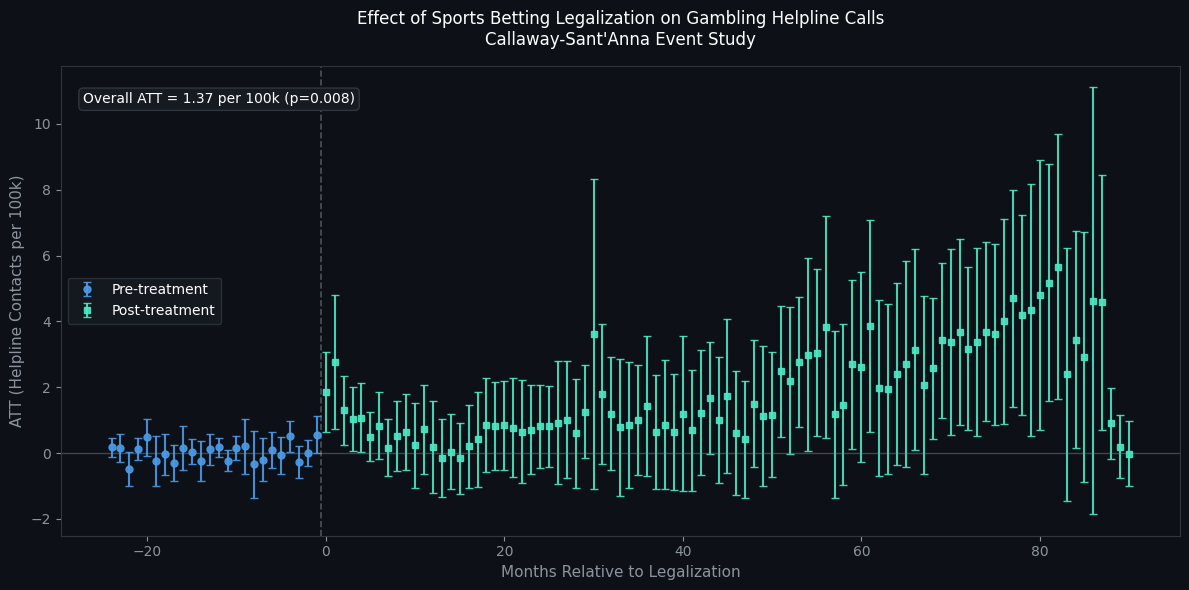

In [3]:
DARK_NAVY  = '#0d1117'
STEEL_BLUE = '#4C9BE8'
TEAL       = '#4CE8C4'
LIGHT_GRAY = '#8B949E'

# Filter to -24 onwards
es_plot = es_df[es_df['relative_period'] >= -24].copy()

pre  = es_plot[es_plot['relative_period'] < 0]
post = es_plot[es_plot['relative_period'] >= 0]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(DARK_NAVY)
ax.set_facecolor(DARK_NAVY)

ax.errorbar(pre['relative_period'], pre['effect'],
            yerr=1.96 * pre['se'], fmt='o', color=STEEL_BLUE,
            capsize=3, linewidth=1.5, markersize=5, label='Pre-treatment', alpha=0.9)

ax.errorbar(post['relative_period'], post['effect'],
            yerr=1.96 * post['se'], fmt='s', color=TEAL,
            capsize=3, linewidth=1.5, markersize=5, label='Post-treatment', alpha=0.9)

ax.axhline(y=0, color=LIGHT_GRAY, linewidth=1, alpha=0.4)
ax.axvline(x=-0.5, color=LIGHT_GRAY, linestyle='--', linewidth=1.2, alpha=0.5)

ax.set_xlabel('Months Relative to Legalization', color=LIGHT_GRAY, fontsize=11)
ax.set_ylabel('ATT (Helpline Contacts per 100k)', color=LIGHT_GRAY, fontsize=11)
ax.set_title('Effect of Sports Betting Legalization on Gambling Helpline Calls\nCallaway-Sant\'Anna Event Study',
             color='white', fontsize=12, pad=15)

ax.tick_params(colors=LIGHT_GRAY)
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='white', fontsize=10)

# Annotate overall ATT
ax.annotate(f'Overall ATT = 1.37 per 100k (p=0.008)',
            xy=(0.02, 0.92), xycoords='axes fraction',
            color='white', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#161b22', edgecolor='#30363d'))

plt.tight_layout()
plt.show()

In [7]:
fig.savefig('../results/event_study_plot.png', dpi=300, bbox_inches='tight')